In [1]:
!pip -q -q install torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1
!pip -q -q install causal-conv1d==1.4.0 --no-build-isolation
!pip -q -q install mamba-ssm==2.2.4 --no-build-isolation
!pip -q -q install mambavision timm pillow
!pip -q -q install "transformers>=4.43" "accelerate>=0.33" "datasets>=2.19" "evaluate>=0.4" "peft>=0.12.0" "scikit-learn>=1.3" "bitsandbytes>=0.43.0"
!pip -q -q install pennylane pennylane-lightning[gpu]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.0/797.0 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 115.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import warnings, random, numpy as np, time, gc, scipy.stats, json, pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import pennylane as qml
from datetime import datetime
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
from transformers import (
    AutoModelForImageClassification, TrainingArguments, Trainer,
    set_seed, TrainerCallback, EarlyStoppingCallback, AutoConfig
)
from peft import LoraConfig, get_peft_model
import transformers.utils.import_utils
import transformers.modeling_utils
import matplotlib.pyplot as plt

transformers.utils.import_utils.check_torch_load_is_safe = lambda: None
transformers.modeling_utils.check_torch_load_is_safe = lambda: None

gc.collect()
torch.cuda.empty_cache()
torch.backends.cudnn.benchmark = True

seed = 42
set_seed(seed); random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"

/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(
2025-12-27 12:22:37.062004: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766838157.436400      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766838157.550796      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766838158.503977      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid li

In [3]:
DATA_PATH = "/kaggle/input/mixedtype-wafer-defect-datasets/Wafer_Map_Datasets.npz"
npz = np.load(DATA_PATH, allow_pickle=True)
X = npz["arr_0"]
Y = npz["arr_1"].astype(np.float32)
target_names = ["Center", "Donut", "Edge_Loc", "Edge_Ring", "Loc", "Near_Full", "Scratch", "Random"]

X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, stratify=np.argmax(Y, 1), random_state=seed)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=2/3, stratify=np.argmax(Y_temp, 1), random_state=seed)

stats = ([0.5]*3, [0.5]*3)
train_tf = T.Compose([T.ToPILImage(), T.Grayscale(3), T.Resize((384, 384)), 
                      T.RandomHorizontalFlip(), T.RandomVerticalFlip(), T.RandomRotation(15), 
                      T.ToTensor(), T.Normalize(*stats)])
val_tf = T.Compose([T.ToPILImage(), T.Grayscale(3), T.Resize((384, 384)), 
                    T.ToTensor(), T.Normalize(*stats)])

class WaferDataset(Dataset):
    def __init__(self, x, y, tf): self.x, self.y, self.tf = x, y, tf
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return {"pixel_values": self.tf(self.x[i]), "labels": torch.tensor(self.y[i], dtype=torch.float32)}

train_ds, val_ds, test_ds = WaferDataset(X_train, Y_train, train_tf), WaferDataset(X_val, Y_val, val_tf), WaferDataset(X_test, Y_test, val_tf)
def collate_fn(b): return {"pixel_values": torch.stack([x["pixel_values"] for x in b]), "labels": torch.stack([x["labels"] for x in b])}

In [4]:
model_name = "timm/vit_small_patch16_384.augreg_in1k"
config = AutoConfig.from_pretrained(model_name)
config.num_labels = 8 
core = AutoModelForImageClassification.from_pretrained(model_name, config=config, trust_remote_code=True, ignore_mismatched_sizes=True).to(device)
peft_config = LoraConfig(r=64, lora_alpha=128, target_modules=["qkv"], modules_to_save=None)
core = get_peft_model(core, peft_config)
core.print_trainable_parameters() 

class UnifiedModel(nn.Module):
    def __init__(self, core, head):
        super().__init__()
        self.core = core
        self.head = head
        self.loss = FocalLoss()
        self._features = None
        target = self.core.base_model
        if hasattr(target, "model"): target = target.model 
        if hasattr(target, "timm_model"): target = target.timm_model
        if hasattr(target, "norm"): layer_to_hook = target.norm
        elif hasattr(target, "fc_norm"): layer_to_hook = target.fc_norm
        else: 
            print(f"Available modules: {list(target._modules.keys())}")
            raise AttributeError("Could not find norm layer.")
            
        layer_to_hook.register_forward_hook(self._hook_fn)

    def _hook_fn(self, module, input, output):
        self._features = output

    def forward(self, pixel_values=None, labels=None, **k):
        _ = self.core(pixel_values)
        features = self._features
        if features.dim() == 3: 
            features = features[:, 0, :]
            
        logits = self.head(features)
        
        return {"loss": self.loss(logits, labels) if labels is not None else None, "logits": logits}

class ClassificationHead(nn.Module):
    def __init__(self, d_in, n_classes):
        super().__init__()
        self.norm = nn.LayerNorm(d_in)
        self.fc = nn.Linear(d_in, n_classes)
    def forward(self, x): return self.fc(self.norm(x))
 
class FocalLoss(nn.Module):
    def forward(self, inp, targ):
        if targ.dtype != torch.float32: targ = targ.float()
        bce = F.binary_cross_entropy_with_logits(inp, targ, reduction="none")
        return (1 * (1 - torch.exp(-bce)) ** 2 * bce).mean()

model = UnifiedModel(core, ClassificationHead(384, 8).to(device)).to(device)

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

model.safetensors:   0%|          | 0.00/88.8M [00:00<?, ?B/s]

Some weights of TimmWrapperForImageClassification were not initialized from the model checkpoint at timm/vit_small_patch16_384.augreg_in1k and are newly initialized because the shapes did not match:
- timm_model.head.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([8]) in the model instantiated
- timm_model.head.weight: found shape torch.Size([1000, 384]) in the checkpoint and torch.Size([8, 384]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 1,179,648 || all params: 22,994,312 || trainable%: 5.1302


In [5]:
def compute_metrics(p):
    preds = (1 / (1 + np.exp(-p.predictions)) > 0.5).astype(int)
    macro_f1 = f1_score(p.label_ids, preds, average="macro", zero_division=0)
    micro_f1 = f1_score(p.label_ids, preds, average="micro", zero_division=0)
    acc = accuracy_score(p.label_ids, preds)
    return {"macro_f1": macro_f1, "micro_f1": micro_f1, "accuracy": acc}

class ClassicalMonitorCallback(TrainerCallback):
    def __init__(self, val_ds):
        self.val_ds = val_ds
        self.logs_list = []
        self.epoch_data = {}
        self.trainer = None

    def on_log(self, args, state, control, model=None, logs=None, **kwargs):
        if not logs: return
        timestamp = datetime.now().isoformat()
        log_msg = f"Step {state.global_step} | Epoch {state.epoch:.2f} | Time: {timestamp}"
        if "loss" in logs: log_msg += f" | Train Loss: {logs['loss']:.4f}"
        if "eval_loss" in logs: log_msg += f" | Val Loss: {logs['eval_loss']:.4f} | Macro-F1: {logs['eval_macro_f1']:.4f} | Micro-F1: {logs['eval_micro_f1']:.4f} | Acc: {logs['eval_accuracy']:.4f}"
        print(log_msg)
        self.logs_list.append({"step": state.global_step, "epoch": state.epoch, "timestamp": timestamp, **logs})

    def on_epoch_end(self, args, state, control, **kwargs):
        if self.trainer:
            preds = self.trainer.predict(self.val_ds)
            logits = preds.predictions
            probs = 1 / (1 + np.exp(-logits))
            self.epoch_data[int(state.epoch)] = {"logits": logits.tolist(), "probs": probs.tolist(), "labels": preds.label_ids.tolist()}

args = TrainingArguments(
    output_dir="out_VisionTransformer_Wafer",
    learning_rate=6e-4,            
    fp16=True,
    per_device_train_batch_size=64, 
    gradient_accumulation_steps=2,
    num_train_epochs=15, 
    dataloader_num_workers=4,
    dataloader_pin_memory=True,
    dataloader_persistent_workers=True,
    optim="adamw_torch_fused", 
    lr_scheduler_type="cosine", 
    warmup_ratio=0.1,
    logging_steps=20,
    eval_strategy="epoch", 
    save_strategy="epoch", 
    load_best_model_at_end=True, 
    metric_for_best_model="macro_f1", 
    report_to="none"
)

monitor_callback = ClassicalMonitorCallback(val_ds)
trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds, 
                  data_collator=collate_fn, compute_metrics=compute_metrics, 
                  callbacks=[monitor_callback, EarlyStoppingCallback(3)])
monitor_callback.trainer = trainer

print("Starting Training...")
trainer.train()

Starting Training...


Epoch,Training Loss,Validation Loss,Macro F1,Micro F1,Accuracy
1,0.091600,0.035179,0.856774,0.911675,0.675612
2,0.023700,0.010545,0.965109,0.980322,0.923967
3,0.018700,0.006559,0.970164,0.988424,0.954486
4,0.015500,0.007148,0.957208,0.985723,0.945804
5,0.011500,0.004201,0.975674,0.992913,0.972639
6,0.009800,0.004414,0.977827,0.992671,0.971586
7,0.008800,0.005499,0.977422,0.989422,0.960537
8,0.007800,0.003789,0.977223,0.993322,0.972639
9,0.006300,0.003222,0.982496,0.994291,0.977374
10,0.006400,0.003110,0.983618,0.994855,0.979742


Step 20 | Epoch 0.10 | Time: 2025-12-27T12:23:32.543350 | Train Loss: 0.4007
Step 40 | Epoch 0.19 | Time: 2025-12-27T12:23:53.194333 | Train Loss: 0.2502
Step 60 | Epoch 0.29 | Time: 2025-12-27T12:24:14.463740 | Train Loss: 0.2176
Step 80 | Epoch 0.38 | Time: 2025-12-27T12:24:36.415302 | Train Loss: 0.1997
Step 100 | Epoch 0.48 | Time: 2025-12-27T12:24:59.343408 | Train Loss: 0.1906
Step 120 | Epoch 0.58 | Time: 2025-12-27T12:25:23.201490 | Train Loss: 0.1677
Step 140 | Epoch 0.67 | Time: 2025-12-27T12:25:46.014212 | Train Loss: 0.1446
Step 160 | Epoch 0.77 | Time: 2025-12-27T12:26:08.564857 | Train Loss: 0.1294
Step 180 | Epoch 0.87 | Time: 2025-12-27T12:26:31.530100 | Train Loss: 0.1148
Step 200 | Epoch 0.96 | Time: 2025-12-27T12:26:54.660767 | Train Loss: 0.0916
Step 208 | Epoch 1.00 | Time: 2025-12-27T12:27:34.184773 | Val Loss: 0.0352 | Macro-F1: 0.8568 | Micro-F1: 0.9117 | Acc: 0.6756
Step 220 | Epoch 1.06 | Time: 2025-12-27T12:27:49.199747 | Train Loss: 0.0762
Step 240 | Epoch 1

TrainOutput(global_step=3120, training_loss=0.023026713685920606, metrics={'train_runtime': 4006.8134, 'train_samples_per_second': 99.618, 'train_steps_per_second': 0.779, 'total_flos': 0.0, 'train_loss': 0.023026713685920606, 'epoch': 15.0})

In [6]:
save_path = "VisionTransformer_Wafer_Model.pth"
model_to_save = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
torch.save(model_to_save.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to VisionTransformer_Wafer_Model.pth


In [7]:
print("Extracting Final Test Data...")
test_output = trainer.predict(test_ds)
logits = test_output.predictions
probs = 1 / (1 + np.exp(-logits))
labels = test_output.label_ids
data_dump = {
    "training_logs": monitor_callback.logs_list,
    "epoch_history": monitor_callback.epoch_data,
    "test_data": {"logits": logits.tolist(), "probs": probs.tolist(), "labels": labels.tolist()}
}

with open("VisionTransformer_Wafer_Results.json", "w") as f:
    json.dump(data_dump, f)

Extracting Final Test Data...


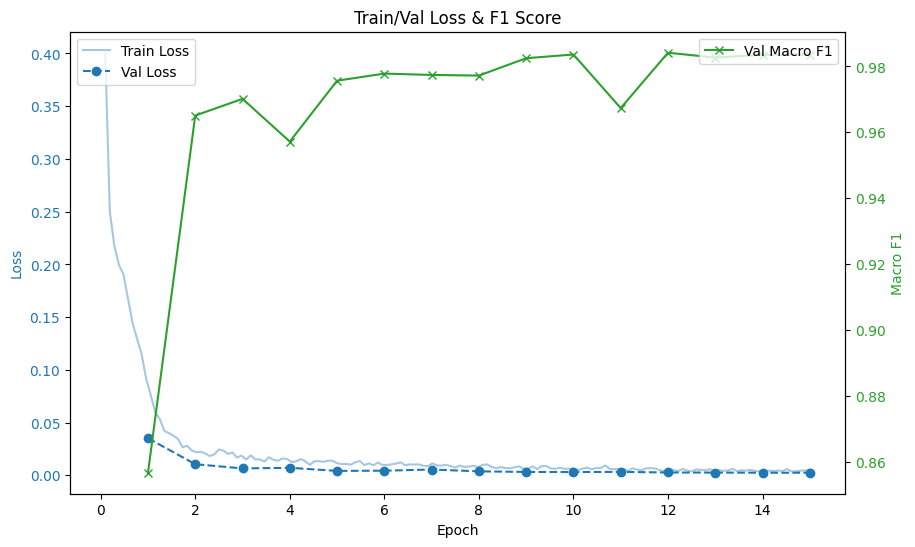

In [8]:
logs = data_dump["training_logs"]
t_loss = [(x["epoch"], x["loss"]) for x in logs if "loss" in x]
v_loss = [(x["epoch"], x["eval_loss"]) for x in logs if "eval_loss" in x]
v_f1 = [(x["epoch"], x["eval_macro_f1"]) for x in logs if "eval_macro_f1" in x]

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color="tab:blue")
ax1.plot(*zip(*t_loss), label="Train Loss", color="tab:blue", alpha=0.4)
ax1.plot(*zip(*v_loss), label="Val Loss", color="tab:blue", linestyle="--", marker="o")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.set_ylabel("Macro F1", color="tab:green")
ax2.plot(*zip(*v_f1), label="Val Macro F1", color="tab:green", marker="x")
ax2.tick_params(axis="y", labelcolor="tab:green")
ax2.legend(loc="upper right")

plt.title("Train/Val Loss & F1 Score")
plt.show()